# HR Employee Attrition and Workforce Analytics
**Objective:** identify who leaves the company, which factors are linked to attrition, and what HR can do about it.

**Dataset:** IBM HR Analytics Employee Attrition & Performance (Kaggle), 1,470 employees, 35 columns.

## 1. Load data

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='whitegrid')

df = pd.read_csv('../data/WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(df.shape)
df.head()

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 2. Data quality check

In [2]:
df.info()
print('Missing values:', df.isnull().sum().sum())
print('Duplicate rows:', df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

## 3. Cleaning
Drop columns with a single constant value and the row identifier, and create a numeric target.

In [3]:
df = df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'])
df['AttritionFlag'] = (df['Attrition'] == 'Yes').astype(int)
df['AgeGroup'] = pd.cut(df['Age'], [17, 25, 35, 45, 55, 100], labels=['18-25','26-35','36-45','46-55','56+'])
df['IncomeBand'] = pd.cut(df['MonthlyIncome'], [0, 3000, 6000, 10000, float('inf')], labels=['<3K','3K-6K','6K-10K','10K+'])
print('Overall attrition rate: %.1f%%' % (df['AttritionFlag'].mean()*100))

Overall attrition rate: 16.1%


## 4. Exploratory analysis

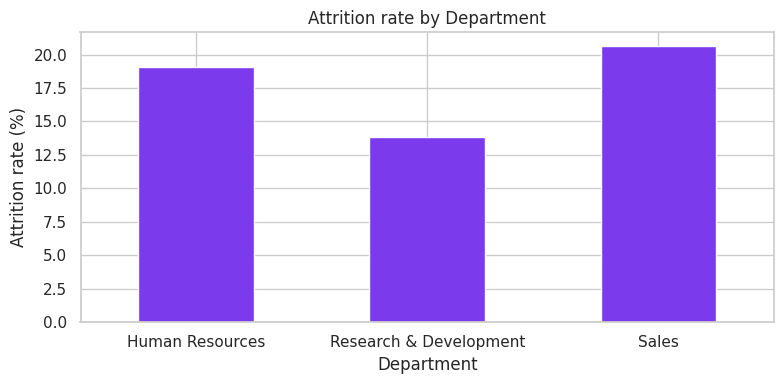

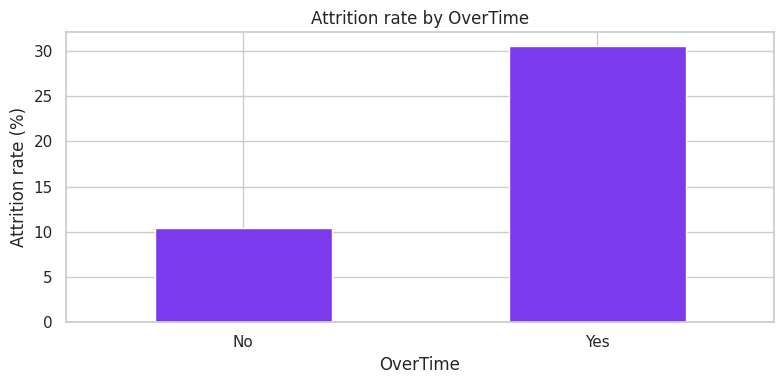

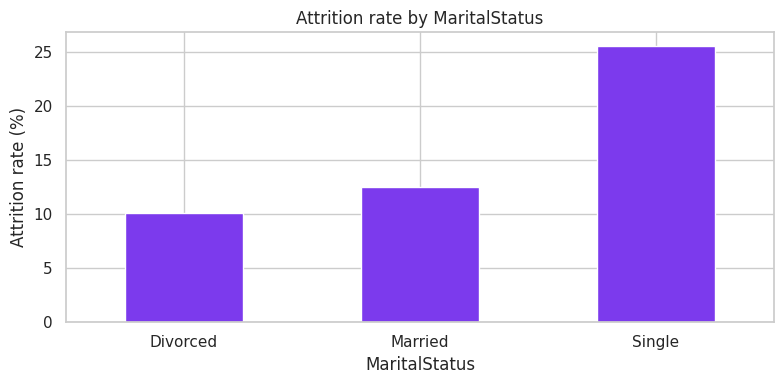

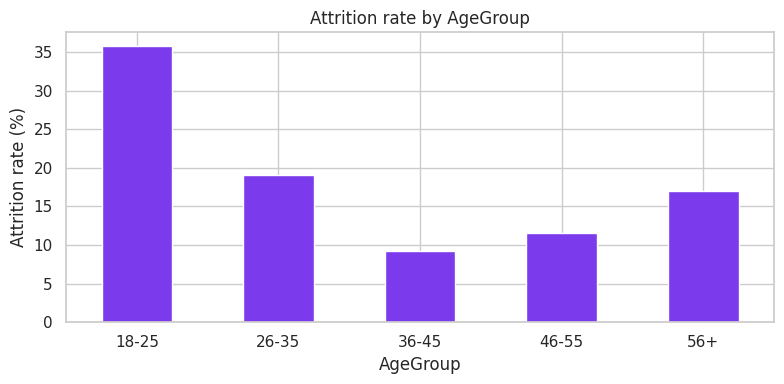

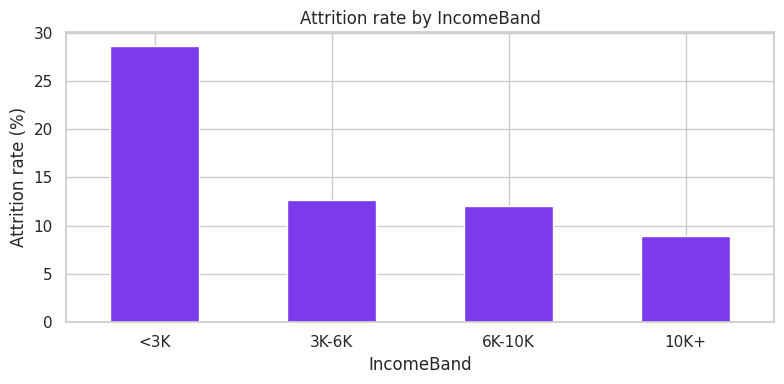

In [4]:
def rate_plot(col, rotate=0):
    r = df.groupby(col, observed=True)['AttritionFlag'].mean().mul(100)
    ax = r.plot(kind='bar', color='#7C3AED', figsize=(8,4))
    ax.set_ylabel('Attrition rate (%)'); ax.set_title(f'Attrition rate by {col}')
    plt.xticks(rotation=rotate); plt.tight_layout(); plt.show()

for col in ['Department', 'OverTime', 'MaritalStatus', 'AgeGroup', 'IncomeBand']:
    rate_plot(col)

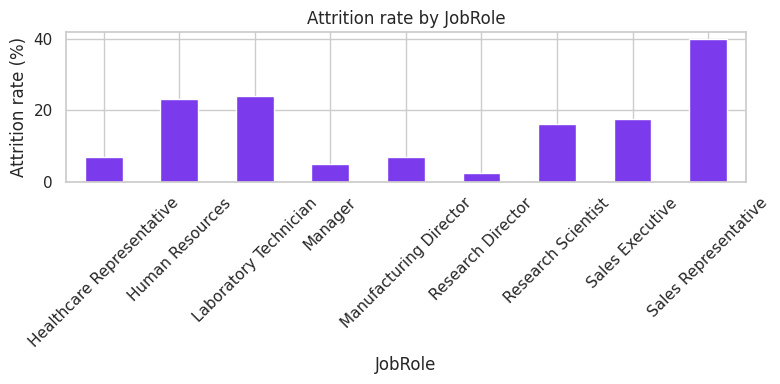

In [5]:
rate_plot('JobRole', rotate=45)

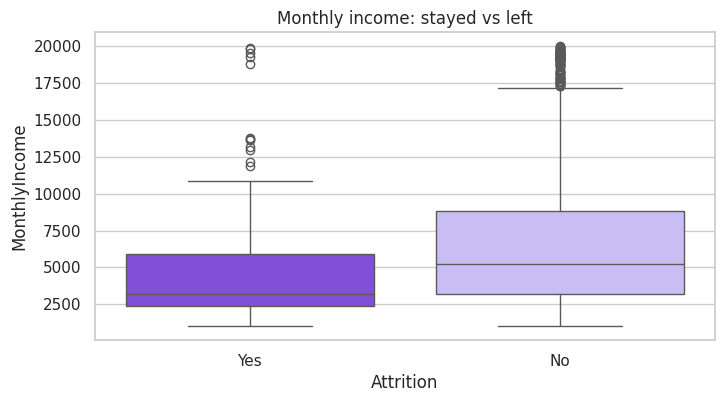

In [6]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', hue='Attrition', palette={'Yes':'#7C3AED','No':'#C4B5FD'}, legend=False)
plt.title('Monthly income: stayed vs left'); plt.show()

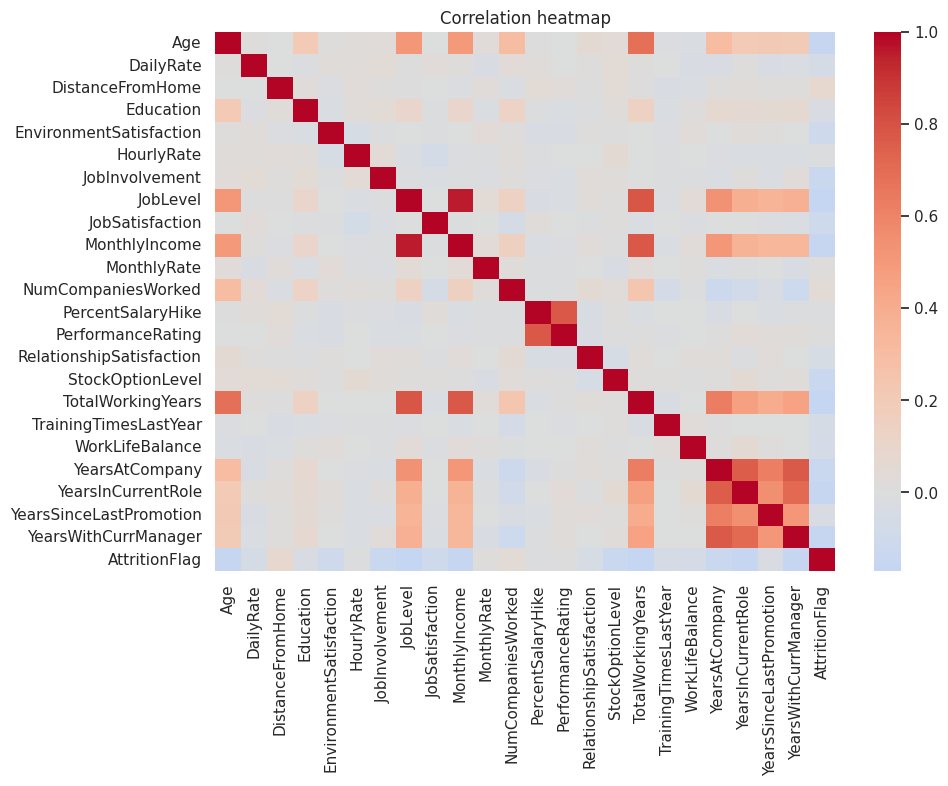

In [7]:
plt.figure(figsize=(10,7))
sns.heatmap(df.select_dtypes('number').corr(), cmap='coolwarm', center=0)
plt.title('Correlation heatmap'); plt.show()

## 5. Predictive model
A class-balanced logistic regression is used because it is easy to explain: each coefficient shows whether a factor raises or lowers attrition risk. Features are standardised so coefficients are comparable.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

X = pd.get_dummies(df.drop(columns=['Attrition','AttritionFlag','AgeGroup','IncomeBand']), drop_first=True)
y = df['AttritionFlag']
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

model = make_pipeline(StandardScaler(), LogisticRegression(class_weight='balanced', C=0.1, max_iter=2000)).fit(X_tr, y_tr)
prob = model.predict_proba(X_te)[:, 1]
print(classification_report(y_te, (prob >= 0.5).astype(int)))
print('ROC AUC: %.2f' % roc_auc_score(y_te, prob))
print(confusion_matrix(y_te, (prob >= 0.5).astype(int)))

              precision    recall  f1-score   support

           0       0.92      0.81      0.86       309
           1       0.39      0.64      0.48        59

    accuracy                           0.78       368
   macro avg       0.65      0.72      0.67       368
weighted avg       0.84      0.78      0.80       368

ROC AUC: 0.81
[[249  60]
 [ 21  38]]


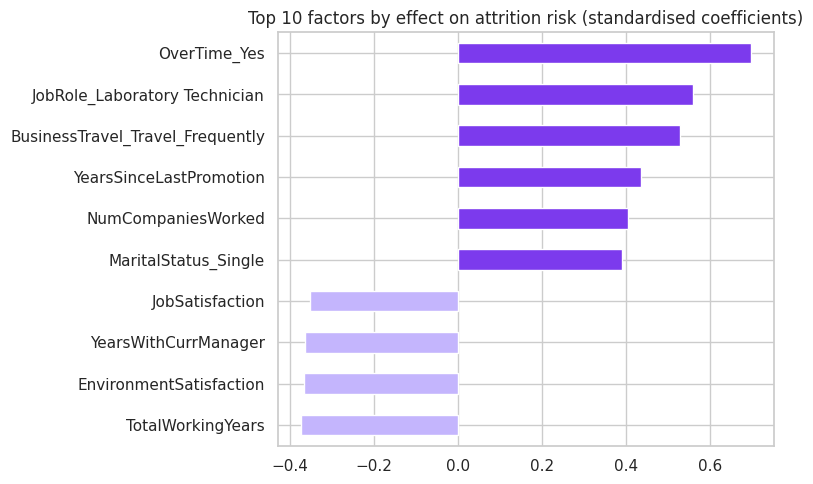

In [9]:
coef = pd.Series(model[-1].coef_[0], index=X.columns)
top = coef.reindex(coef.abs().sort_values(ascending=False).head(10).index).sort_values()
top.plot(kind='barh', color=['#7C3AED' if v > 0 else '#C4B5FD' for v in top], figsize=(8,5),
         title='Top 10 factors by effect on attrition risk (standardised coefficients)')
plt.tight_layout(); plt.show()

## 6. Conclusions and recommendations
**Findings**
1. Overall attrition is 16.1% (237 of 1,470 employees).
2. Overtime is the clearest signal: 30.5% of employees working overtime left, against 10.4% of those who did not.
3. Sales Representatives have the highest attrition (39.8%), followed by Laboratory Technicians (23.9%) and Human Resources roles (23.1%). Research Directors (2.5%) and Managers (4.9%) are the most stable.
4. Attrition falls with age, income and tenure: 35.8% for ages 18-25 versus 9.2% for 36-45; 28.6% below $3K monthly income versus 8.9% above $10K; 29.8% in the first two years versus 8.1% after ten.
5. Single employees leave at 25.5%, roughly double the rate of married (12.5%) and divorced (10.1%) employees. Frequent travellers leave at 24.9% versus 8.0% for non-travellers.

**Recommendations**
1. Review workload and staffing where overtime is heavy, and track overtime per team.
2. Prioritise retention for Sales Representative and Laboratory Technician roles (career paths, pay review, stay interviews).
3. Strengthen onboarding and mentoring in the first two years.
4. Benchmark pay for the lowest income band.
5. Limit frequent-travel expectations where the role allows.

**Limitations:** the dataset is fictional, so the numbers illustrate the method rather than a real company. The model shows association, not causation.